# COMPARATIVA RATAS SANAS VS ALCOHÓLICAS
## Análisis de velocidades de conducción axonal (TH=0.0)
**Datos Alejandro - Dic 2024**

---

### Objetivo
Comparar distribuciones de velocidades de conducción entre grupos healthy (n=18) y alcoholic (n=18) para identificar cambios estructurales en conectividad.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import os
from pathlib import Path
from scipy import stats
from scipy.stats import entropy, skew, kurtosis
from sklearn.preprocessing import LabelEncoder, StandardScaler
import seaborn as sns
from collections import Counter

# Helper functions
def make_name_map_from_ids(roi_names, left_ids, right_ids):
    """Mapea IDs reales a nombres L-/R- de ROIs"""
    if len(left_ids) != len(roi_names) or len(right_ids) != len(roi_names):
        raise ValueError("IDs deben tener la misma longitud que roi_names")
    name_map = {}
    for k, rid in enumerate(left_ids):
        name_map[int(rid)] = f"L-{roi_names[k]}"
    for k, rid in enumerate(right_ids):
        name_map[int(rid)] = f"R-{roi_names[k]}"
    return name_map

def roi_label(idx, name_map):
    """Devuelve label de ROI desde ID"""
    try:
        return name_map[int(idx)]
    except KeyError:
        return f"ID{int(idx)}"

---
## 1. CARGA DE DATOS

In [2]:
# Cambiar directorio si es necesario
os.chdir("../..") if os.getcwd().endswith('data_analysis') else None

# Cargar nombres ROI
path = './data/raw/'
names = [f for f in os.listdir(path) if 'name' in f.lower()]

if names:
    with open(path + names[0], 'r') as f:
        roi_names = [line.strip() for line in f.readlines()][1:]

print(f"✓ ROIs cargados: {len(roi_names)}")
print(f"Primeros 5: {roi_names[:5]}")

✓ ROIs cargados: 78
Primeros 5: ['White matter', 'Ventricles', 'Superior colliculus', 'Olfactory bulb', 'Lateral lemniscus']


In [3]:
def load_all_rats(data_dir, threshold='0.0', condition='healthy'):
    """Carga archivos .dat de todas las ratas"""
    rats = {}
    path = Path(data_dir) / f'rat_delays_fibers_{threshold}' / f'th-{threshold}_{condition}'
    
    for rat_dir in sorted(path.glob('R*')):
        if not rat_dir.is_dir():
            continue
        rat_id = rat_dir.name
        dat_file = rat_dir / f'th-{threshold}_{rat_id}_b20_r_Fit_Histogram_Tau_all_fibers.dat'
        
        if dat_file.exists():
            with open(dat_file, 'rb') as fh:
                rats[rat_id] = pickle.load(fh)
    return rats

# Cargar ambos grupos
healthy_rats = load_all_rats('./data/raw/', threshold='0.0', condition='healthy')
alcoholic_rats = load_all_rats('./data/raw/', threshold='0.0', condition='alcoholic')

print(f"✓ Healthy: {len(healthy_rats)} ratas")
print(f"✓ Alcoholic: {len(alcoholic_rats)} ratas")

# Info estructura
if healthy_rats:
    first_h = list(healthy_rats.keys())[0]
    sample_pair = list(healthy_rats[first_h].keys())[0]
    sample_data = np.array(healthy_rats[first_h][sample_pair])
    print(f"✓ Conexiones por rata: ~{len(healthy_rats[first_h])}")
    print(f"✓ Ejemplo par {sample_pair}: {sample_data.shape[0]} fibras")
    print(f"✓ Columnas: [tau, distancia, velocidad, ...]")

✓ Healthy: 18 ratas
✓ Alcoholic: 18 ratas
✓ Conexiones por rata: ~3937
✓ Ejemplo par (3, 4): 13 fibras
✓ Columnas: [tau, distancia, velocidad, ...]


In [4]:
# Mapeo de IDs
left_ids = range(0, 78)
right_ids = range(78, 156)
name_map = make_name_map_from_ids(roi_names, left_ids, right_ids)

# Análisis de pares comunes
pairs_healthy = Counter()
pairs_alcoholic = Counter()

for rat_data in healthy_rats.values():
    pairs_healthy.update(rat_data.keys())
for rat_data in alcoholic_rats.values():
    pairs_alcoholic.update(rat_data.keys())

pairs_h_set = set(pairs_healthy.keys())
pairs_a_set = set(pairs_alcoholic.keys())
common_pairs = pairs_h_set & pairs_a_set

print(f"{'='*70}")
print(f"HEALTHY:")
print(f"  Total conexiones únicas: {len(pairs_healthy)}")
print(f"  Conexiones en 18 ratas: {sum(1 for c in pairs_healthy.values() if c == 18)}")

print(f"\nALCOHOLIC:")
print(f"  Total conexiones únicas: {len(pairs_alcoholic)}")
print(f"  Conexiones en 18 ratas: {sum(1 for c in pairs_alcoholic.values() if c == 18)}")

print(f"\nCOMPARATIVA:")
print(f"  Pares comunes: {len(common_pairs)}")
print(f"  Solo healthy: {len(pairs_h_set - pairs_a_set)}")
print(f"  Solo alcoholic: {len(pairs_a_set - pairs_h_set)}")

HEALTHY:
  Total conexiones únicas: 7263
  Conexiones en 18 ratas: 1470

ALCOHOLIC:
  Total conexiones únicas: 7021
  Conexiones en 18 ratas: 1328

COMPARATIVA:
  Pares comunes: 6273
  Solo healthy: 990
  Solo alcoholic: 748


---
## 2. CONSTRUCCIÓN DE DATAFRAMES

**Nivel rata individual**: Una fila por cada conexión (i→j) en cada rata

In [5]:
COL_TAU = 0
COL_D = 1
COL_V = 2

def build_rat_level_df(rats_dict, condition):
    """Extrae velocidades y construye DataFrame por rata"""
    rows = []
    for rat_id, rat_data in rats_dict.items():
        for (i, j), fibers in rat_data.items():
            if np.array(fibers).shape[0] == 0:
                continue
            velocities = np.array(fibers)[:, COL_V]
            rows.append({
                'rat_id': rat_id,
                'condition': condition,
                'roi_i': i,
                'roi_j': j,
                'mean_velocity': np.mean(velocities),
                'std_velocity': np.std(velocities),
                'min_velocity': velocities.min(),
                'max_velocity': velocities.max(),
                'median_velocity': np.median(velocities),
                'q25_velocity': np.percentile(velocities, 25),
                'q75_velocity': np.percentile(velocities, 75),
                'n_fibers': len(velocities)
            })
    return pd.DataFrame(rows)

df_healthy = build_rat_level_df(healthy_rats, 'healthy')
df_alcoholic = build_rat_level_df(alcoholic_rats, 'alcoholic')
df_all_rats = pd.concat([df_healthy, df_alcoholic], ignore_index=True)

print(f"✓ DataFrame nivel rata:")
print(f"  Healthy: {len(df_healthy)} conexiones-rata")
print(f"  Alcoholic: {len(df_alcoholic)} conexiones-rata")
print(f"  Total: {len(df_all_rats)} filas")

✓ DataFrame nivel rata:
  Healthy: 63634 conexiones-rata
  Alcoholic: 61059 conexiones-rata
  Total: 124693 filas


---
## 3. AGREGACIÓN POR PARES

Promediar métricas entre ratas para cada par (i→j), filtrando por robustez (≥9 ratas, ≥50 fibras)

In [6]:
def aggregate_by_pair(df, min_rats=9, min_fibers=50):
    """Agrega métricas por par (roi_i, roi_j)"""
    grouped = df.groupby(['condition', 'roi_i', 'roi_j']).agg({
        'mean_velocity': ['mean', 'std', 'median'],
        'std_velocity': 'mean',
        'n_fibers': ['mean', 'sum'],
        'rat_id': 'count'
    }).reset_index()
    
    grouped.columns = ['condition', 'roi_i', 'roi_j', 
                       'mean_velocity', 'std_between_rats', 'median_velocity',
                       'mean_std_within_rat', 'mean_n_fibers', 'total_fibers', 'n_rats']
    
    grouped['cv_inter_rat'] = grouped['std_between_rats'] / grouped['mean_velocity']
    
    filtered = grouped[
        (grouped['n_rats'] >= min_rats) & 
        (grouped['mean_n_fibers'] >= min_fibers)
    ].copy()
    
    return filtered

df_agg = aggregate_by_pair(df_all_rats, min_rats=9, min_fibers=50)

print(f"✓ Pares agregados (≥9 ratas, ≥50 fibras/rata):")
print(f"  Total: {len(df_agg)}")
print(f"  Healthy: {len(df_agg[df_agg.condition=='healthy'])}")
print(f"  Alcoholic: {len(df_agg[df_agg.condition=='alcoholic'])}")

✓ Pares agregados (≥9 ratas, ≥50 fibras/rata):
  Total: 4362
  Healthy: 2161
  Alcoholic: 2201


---
## 4. MATRICES DE VELOCIDAD

Visualización espacial de diferencias entre grupos

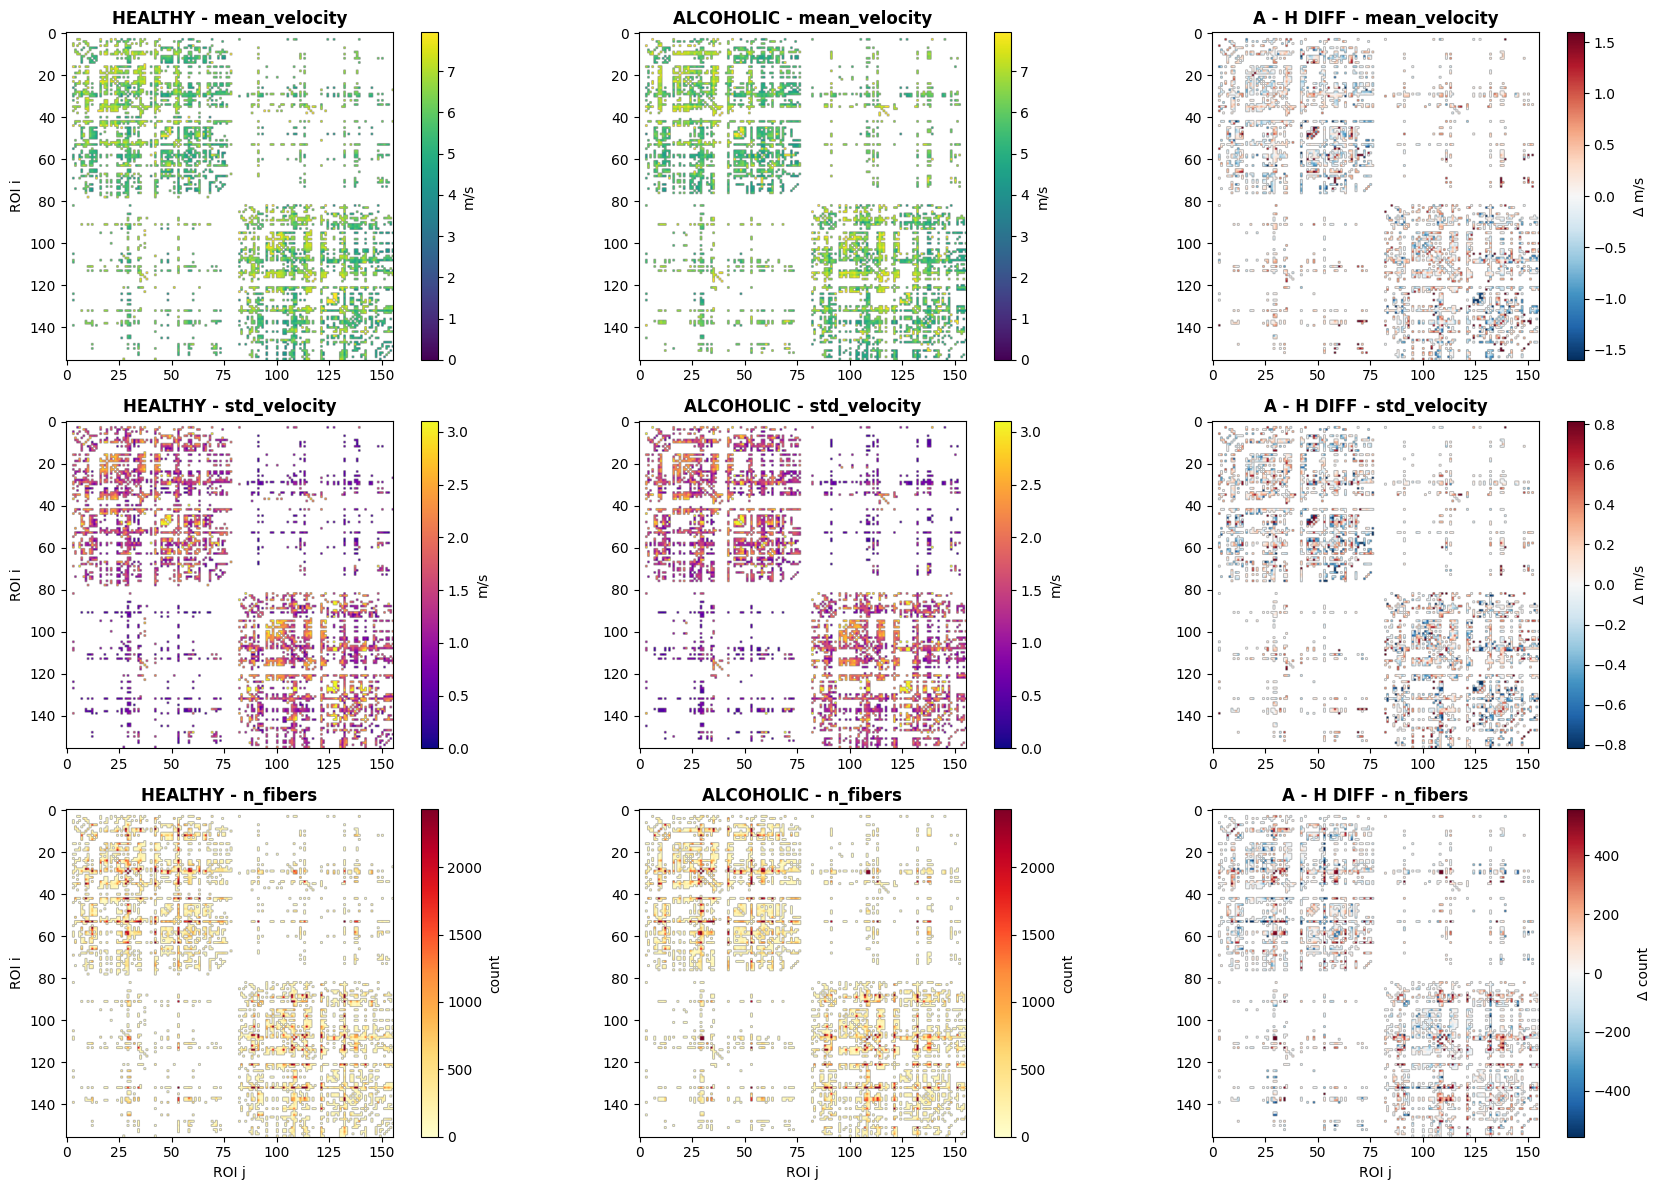

METRIC          |          HEALTHY          |         ALCOHOLIC         |        DIFFERENCE        

MEAN_VELOCITY:
  Mean:   6.002378 |   6.033411 |   0.059359 ± 0.625802

STD_VELOCITY:
  Mean:   1.506459 |   1.507465 |   0.017849 ± 0.380461

N_FIBERS:
  Mean: 373.384329 | 383.397712 |  21.348030 ± 237.213560


In [8]:
# Filtrar datos para matrices
df_healthy_filt = df_healthy.groupby(['roi_i', 'roi_j']).filter(
    lambda x: len(x) >= 9 and x['n_fibers'].mean() >= 50
)
df_alcoholic_filt = df_alcoholic.groupby(['roi_i', 'roi_j']).filter(
    lambda x: len(x) >= 9 and x['n_fibers'].mean() >= 50
)

def build_matrix(df, metric='mean_velocity'):
    """Construye matriz 156x156 de velocities, promediando entre ratas"""
    # Agrupar por par y promediar
    grouped = df.groupby(['roi_i', 'roi_j'])[metric].mean()
    
    # Matriz simétrica
    matrix = np.full((156, 156), np.nan)
    for (i, j), val in grouped.items():
        try:
            matrix[i, j] = val
            matrix[j, i] = val  # simetrizar
        except:
            pass
    
    return matrix


# Métricas a visualizar
metrics_info = {
    'mean_velocity': {'cmap': 'viridis', 'unit': 'm/s'},
    'std_velocity': {'cmap': 'plasma', 'unit': 'm/s'},
    'n_fibers': {'cmap': 'YlOrRd', 'unit': 'count'}
}

matrices = {}
for metric in metrics_info.keys():
    mat_h = build_matrix(df_healthy_filt, metric=metric)
    mat_a = build_matrix(df_alcoholic_filt, metric=metric)
    matrices[metric] = {
        'healthy': mat_h,
        'alcoholic': mat_a,
        'diff': mat_a - mat_h
    }

# Visualización
fig, axes = plt.subplots(len(metrics_info), 3, figsize=(18, 4*len(metrics_info)))

for idx, (metric, info) in enumerate(metrics_info.items()):
    mat_h = matrices[metric]['healthy']
    mat_a = matrices[metric]['alcoholic']
    mat_d = matrices[metric]['diff']
    
    vmax = np.nanpercentile([mat_h, mat_a], 98)
    vmin_diff = np.nanpercentile(mat_d, 2)
    vmax_diff = np.nanpercentile(mat_d, 98)
    
    # Healthy
    im1 = axes[idx, 0].imshow(mat_h, cmap=info['cmap'], vmin=0, vmax=vmax)
    axes[idx, 0].set_title(f'HEALTHY - {metric}', fontweight='bold')
    axes[idx, 0].set_ylabel('ROI i')
    plt.colorbar(im1, ax=axes[idx, 0], fraction=0.046, label=info['unit'])
    
    # Alcoholic
    im2 = axes[idx, 1].imshow(mat_a, cmap=info['cmap'], vmin=0, vmax=vmax)
    axes[idx, 1].set_title(f'ALCOHOLIC - {metric}', fontweight='bold')
    plt.colorbar(im2, ax=axes[idx, 1], fraction=0.046, label=info['unit'])
    
    # Diff
    abs_max = max(abs(vmin_diff), abs(vmax_diff))
    im3 = axes[idx, 2].imshow(mat_d, cmap='RdBu_r', vmin=-abs_max, vmax=abs_max)
    axes[idx, 2].set_title(f'A - H DIFF - {metric}', fontweight='bold')
    plt.colorbar(im3, ax=axes[idx, 2], fraction=0.046, label=f'Δ {info["unit"]}')
    
    if idx == len(metrics_info)-1:
        for ax in axes[idx]:
            ax.set_xlabel('ROI j')

plt.tight_layout()
plt.show()

# Stats numéricas
print("="*100)
print(f"{'METRIC':<15} | {'HEALTHY':^25} | {'ALCOHOLIC':^25} | {'DIFFERENCE':^25}")
print("="*100)

for metric, info in metrics_info.items():
    mat_h = matrices[metric]['healthy']
    mat_a = matrices[metric]['alcoholic']
    mat_d = matrices[metric]['diff']
    
    h_mean = np.nanmean(mat_h)
    a_mean = np.nanmean(mat_a)
    d_mean = np.nanmean(mat_d)
    d_std = np.nanstd(mat_d)
    
    print(f"\n{metric.upper()}:")
    print(f"  Mean: {h_mean:>10.6f} | {a_mean:>10.6f} | {d_mean:>10.6f} ± {d_std:<8.6f}")

print("="*100)

---
## 5. DISTRIBUCIONES Y TEST ESTADÍSTICO

Comparar distribuciones globales con Kolmogorov-Smirnov

KeyError: 'max_velocity'

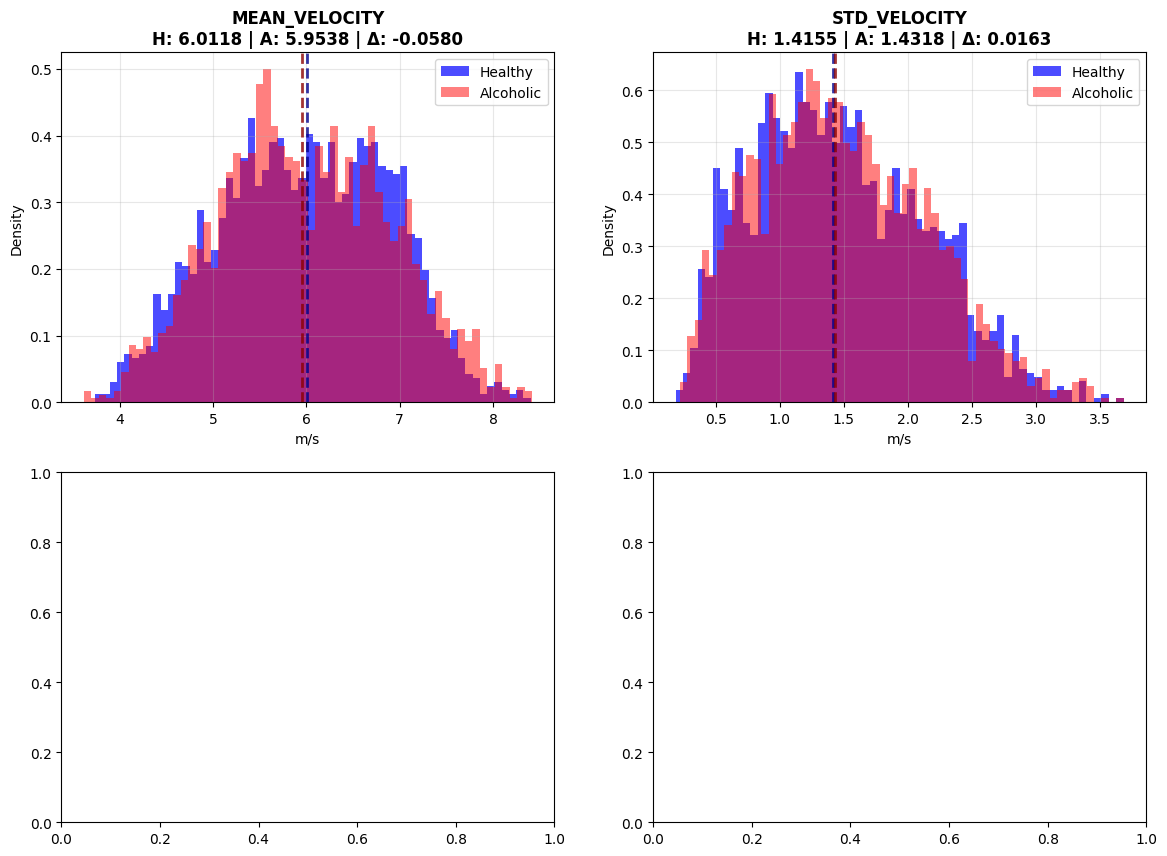

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

metrics_to_plot = ['mean_velocity', 'std_velocity', 'max_velocity', 'n_fibers']

for idx, metric in enumerate(metrics_to_plot):
    mat_h = matrices[metric]['healthy']
    mat_a = matrices[metric]['alcoholic']
    
    data_h = mat_h[~np.isnan(mat_h)].flatten()
    data_a = mat_a[~np.isnan(mat_a)].flatten()
    
    # Recortar outliers para visualización
    if metric != 'n_fibers':
        vmax = np.percentile(np.concatenate([data_h, data_a]), 99)
        data_h_plot = data_h[data_h <= vmax]
        data_a_plot = data_a[data_a <= vmax]
    else:
        data_h_plot = data_h
        data_a_plot = data_a
    
    axes[idx].hist(data_h_plot, bins=60, alpha=0.7, label='Healthy', 
                   color='blue', density=True, histtype='stepfilled')
    axes[idx].hist(data_a_plot, bins=60, alpha=0.5, label='Alcoholic', 
                   color='red', density=True, histtype='stepfilled')
    
    med_h = np.median(data_h)
    med_a = np.median(data_a)
    axes[idx].axvline(med_h, color='darkblue', linestyle='--', linewidth=2, alpha=0.8)
    axes[idx].axvline(med_a, color='darkred', linestyle='--', linewidth=2, alpha=0.8)
    
    title = f"{metric.upper()}\nH: {med_h:.4f} | A: {med_a:.4f} | Δ: {med_a-med_h:.4f}"
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].set_xlabel(metrics_info.get(metric, {'unit': 'value'})['unit'])
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# KS tests
print("\n" + "="*70)
print("KOLMOGOROV-SMIRNOV TESTS")
print("="*70)
print(f"{'Metric':<20} | {'KS stat':>10} | {'p-value':>12} | {'Sig':>8}")
print("-"*70)

for metric in metrics_to_plot:
    data_h = matrices[metric]['healthy'][~np.isnan(matrices[metric]['healthy'])].flatten()
    data_a = matrices[metric]['alcoholic'][~np.isnan(matrices[metric]['alcoholic'])].flatten()
    
    ks_stat, p_val = stats.ks_2samp(data_h, data_a)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    print(f"{metric:<20} | {ks_stat:>10.4f} | {p_val:>12.2e} | {sig:>8}")

print("="*70)

---
## 6. FEATURE ENGINEERING

Extracción de features avanzadas desde distribuciones completas

In [ ]:
def compute_advanced_features(rats_dict, condition):
    """Calcula skewness, kurtosis, entropy desde distribuciones"""
    rows = []
    for rat_id, rat_data in rats_dict.items():
        for (i, j), fibers in rat_data.items():
            fibers_arr = np.array(fibers)
            
            if fibers_arr.shape[0] < 3:
                continue
                
            velocities = fibers_arr[:, COL_V]
            sorted_velocities = np.sort(velocities)
            velocity_sum = np.sum(sorted_velocities)
            
            if velocity_sum == 0:
                continue
                
            cumsum_norm = np.cumsum(sorted_velocities) / velocity_sum
            
            rows.append({
                'rat_id': rat_id,
                'condition': condition,
                'roi_i': i,
                'roi_j': j,
                'skewness': skew(velocities),
                'kurtosis': kurtosis(velocities),
                'entropy': entropy(np.histogram(velocities, bins=20)[0] + 1e-10),
                'q90_velocity': np.percentile(velocities, 90),
                'q10_velocity': np.percentile(velocities, 10),
                'mad': np.median(np.abs(velocities - np.median(velocities))),
                'cumsum_auc': np.trapezoid(cumsum_norm, dx=1/len(cumsum_norm))
            })
    return pd.DataFrame(rows)

# Calcular features avanzadas
df_advanced_h = compute_advanced_features(healthy_rats, 'healthy')
df_advanced_a = compute_advanced_features(alcoholic_rats, 'alcoholic')
df_advanced = pd.concat([df_advanced_h, df_advanced_a], ignore_index=True)

# Construir DataFrame completo
df_features = df_all_rats.copy()
df_features['cv_velocity'] = df_features['std_velocity'] / (df_features['mean_velocity'] + 1e-10)
df_features['iqr_velocity'] = df_features['q75_velocity'] - df_features['q25_velocity']
df_features['range_velocity'] = df_features['max_velocity'] - df_features['min_velocity']
df_features['hemisphere_i'] = df_features['roi_i'].apply(lambda x: 'L' if x < 78 else 'R')
df_features['hemisphere_j'] = df_features['roi_j'].apply(lambda x: 'L' if x < 78 else 'R')
df_features['is_interhemispheric'] = (df_features['hemisphere_i'] != df_features['hemisphere_j']).astype(int)
df_features['log_n_fibers'] = np.log10(df_features['n_fibers'] + 1)

# Merge features avanzadas
df_features = df_features.merge(df_advanced, on=['rat_id', 'condition', 'roi_i', 'roi_j'], how='left')

print(f"✓ DataFrame features completo: {df_features.shape}")
print(f"\nColumnas: {list(df_features.columns)}")

In [ ]:
# Filtrar por robustez (≥9 ratas por condición, ≥50 fibras)
df_features_robust = df_features.groupby(['roi_i', 'roi_j']).filter(
    lambda x: (x[x.condition=='healthy'].shape[0] >= 9) and 
              (x[x.condition=='alcoholic'].shape[0] >= 9) and
              (x['n_fibers'] >= 50).all()
)

print(f"Filtrado robusto: {len(df_features)} → {len(df_features_robust)} filas")
print(f"NaNs en features: {df_features_robust[['skewness', 'kurtosis', 'entropy']].isna().sum().to_dict()}")

---
## 7. TESTS ESTADÍSTICOS MULTIVARIADOS

Mann-Whitney U por cada par (i,j) con corrección FDR

In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import fdrcorrection

test_features = [
    'mean_velocity', 'std_velocity', 'max_velocity', 'cv_velocity',
    'mad', 'skewness', 'kurtosis', 'entropy', 'log_n_fibers',
    'is_interhemispheric', 'cumsum_auc'
]

results = []
for feat in test_features:
    for (i, j), group in df_features_robust.groupby(['roi_i', 'roi_j']):
        h_data = group[group.condition == 'healthy'][feat].dropna().values
        a_data = group[group.condition == 'alcoholic'][feat].dropna().values
        
        if len(h_data) >= 5 and len(a_data) >= 5:
            stat, p = mannwhitneyu(h_data, a_data, alternative='two-sided')
            pooled_std = np.sqrt((h_data.std()**2 + a_data.std()**2) / 2)
            cohens_d = (a_data.mean() - h_data.mean()) / (pooled_std + 1e-10)
            
            results.append({
                'feature': feat,
                'roi_i': i,
                'roi_j': j,
                'mean_h': h_data.mean(),
                'mean_a': a_data.mean(),
                'delta': a_data.mean() - h_data.mean(),
                'p_value': p,
                'cohens_d': cohens_d
            })

df_tests = pd.DataFrame(results)

# FDR correction
df_tests['p_fdr'], df_tests['sig_fdr'] = fdrcorrection(df_tests['p_value'], alpha=0.05)
df_tests['abs_cohens_d'] = df_tests['cohens_d'].abs()

print(f"{'='*70}")
print(f"Tests totales: {len(df_tests)}")
print(f"Significativos FDR (q<0.05): {df_tests.sig_fdr.sum()} ({100*df_tests.sig_fdr.mean():.1f}%)")
print(f"\nPor feature:")
for feat in test_features:
    n_sig = df_tests[df_tests.feature==feat].sig_fdr.sum()
    print(f"  {feat:<20}: {n_sig:>4} pares significativos")

print(f"\n{'='*70}")
print(f"Top 10 efectos (|Cohen's d|):")
top = df_tests.nlargest(10, 'abs_cohens_d')
print(top[['feature', 'roi_i', 'roi_j', 'delta', 'cohens_d', 'p_fdr']].to_string(index=False))
print(f"{'='*70}")

---
## 8. CORRELACIONES ENTRE FEATURES

In [ ]:
feature_cols = [
    'mean_velocity', 'std_velocity', 'max_velocity', 'cv_velocity',
    'iqr_velocity', 'range_velocity', 'is_interhemispheric', 'log_n_fibers',
    'skewness', 'kurtosis', 'entropy', 'mad', 'q90_velocity', 'q10_velocity', 'cumsum_auc'
]

corr_mat = df_features_robust[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlaciones entre features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Identificar correlaciones altas (>0.8)
high_corr = []
for i in range(len(corr_mat.columns)):
    for j in range(i+1, len(corr_mat.columns)):
        if abs(corr_mat.iloc[i, j]) > 0.8:
            high_corr.append((corr_mat.columns[i], corr_mat.columns[j], corr_mat.iloc[i, j]))

print(f"\nCorrelaciones altas (|r| > 0.8):")
for f1, f2, r in high_corr:
    print(f"  {f1} ↔ {f2}: {r:.3f}")

---
## 9. CLASIFICACIÓN SUPERVISADA

Decision Tree para identificar features discriminativas

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score

# Preparar datos
test_features = [
    'mean_velocity', 'std_velocity', 'max_velocity', 'cv_velocity',
    'mad', 'skewness', 'kurtosis', 'entropy', 'log_n_fibers',
    'is_interhemispheric', 'cumsum_auc'
]

df_ml = df_features_robust[test_features + ['condition', 'roi_i', 'roi_j']].dropna()

# Añadir par como feature
df_ml['pair_id'] = df_ml['roi_i'].astype(str) + '_' + df_ml['roi_j'].astype(str)
pair_enc = LabelEncoder()
df_ml['pair_encoded'] = pair_enc.fit_transform(df_ml['pair_id'])

X = df_ml[test_features + ['pair_encoded']].values
y = (df_ml['condition'] == 'alcoholic').astype(int).values
feat_names = test_features + ['pair_encoded']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")
print(f"Class balance: {y.mean():.2%} alcoholic")

In [ ]:
# Grid search para max_depth óptimo
cv = StratifiedKFold(5, shuffle=True, random_state=42)
depths = range(3, 21)
cv_scores = []

print("Grid search max_depth...")
for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_validate(dt, X_train, y_train, cv=cv, scoring='accuracy')
    mean_score = scores['test_accuracy'].mean()
    cv_scores.append(mean_score)
    print(f"  depth={depth:2d}: {mean_score:.3f}")

best_depth = depths[np.argmax(cv_scores)]
print(f"\nÓptimo: max_depth={best_depth}, CV accuracy={max(cv_scores):.3f}")

# Entrenar modelo óptimo
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)

# Métricas completas
cv_metrics = cross_validate(dt, X_train, y_train, cv=cv,
                           scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

print(f"\n{'='*70}")
print(f"MÉTRICAS CROSS-VALIDATION (5-fold):")
print(f"{'='*70}")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    vals = cv_metrics[f'test_{metric}']
    print(f"  {metric:<12}: {vals.mean():.3f} ± {vals.std():.3f}")

# Predicciones
y_train_pred = dt.predict(X_train)
y_train_proba = dt.predict_proba(X_train)[:, 1]
y_test_pred = dt.predict(X_test)
y_test_proba = dt.predict_proba(X_test)[:, 1]

print(f"\n{'='*70}")
print(f"PERFORMANCE TRAIN/TEST:")
print(f"{'='*70}")
print(f"Train accuracy: {dt.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {dt.score(X_test, y_test):.3f}")
print(f"\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Healthy', 'Alcoholic']))

# Feature importance
importances = pd.DataFrame({
    'feature': feat_names,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n{'='*70}")
print(f"FEATURE IMPORTANCE RANKING:")
print(f"{'='*70}")
print(importances.to_string(index=False))

In [ ]:
# Visualización completa
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3)

# 1. Árbol de decisión
ax1 = fig.add_subplot(gs[0:2, 0:2])
plot_tree(dt, ax=ax1, feature_names=feat_names, class_names=['H', 'A'],
          filled=True, fontsize=7, rounded=True)
ax1.set_title(f'Decision Tree (depth={best_depth})', fontweight='bold')

# 2. Feature importance
ax2 = fig.add_subplot(gs[0, 2])
ax2.barh(importances.head(10)['feature'], importances.head(10)['importance'])
ax2.set_xlabel('Importance')
ax2.set_title('Top 10 Features', fontweight='bold')

# 3. ROC Curve
ax3 = fig.add_subplot(gs[1, 2])
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)
ax3.plot(fpr_train, tpr_train, color='blue', lw=2, label=f'Train (AUC={auc_train:.2f})')
ax3.plot(fpr_test, tpr_test, color='red', lw=2, label=f'Test (AUC={auc_test:.2f})')
ax3.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax3.set_xlabel('FPR')
ax3.set_ylabel('TPR')
ax3.set_title('ROC Curve', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Confusion Matrix Train
ax4 = fig.add_subplot(gs[2, 0])
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['H', 'A'], yticklabels=['H', 'A'])
ax4.set_title('Confusion Matrix (Train)', fontweight='bold')
ax4.set_ylabel('True')
ax4.set_xlabel('Predicted')

# 5. Confusion Matrix Test
ax5 = fig.add_subplot(gs[2, 1])
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=ax5,
            xticklabels=['H', 'A'], yticklabels=['H', 'A'])
ax5.set_title('Confusion Matrix (Test)', fontweight='bold')
ax5.set_ylabel('True')
ax5.set_xlabel('Predicted')

# 6. CV metrics
ax6 = fig.add_subplot(gs[2, 2])
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC'],
    'Score': [cv_metrics[f'test_{m}'].mean() for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
})
ax6.barh(metrics_df['Metric'], metrics_df['Score'])
ax6.set_xlim([0, 1])
ax6.set_xlabel('Score')
ax6.set_title('CV Metrics', fontweight='bold')
ax6.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

---
## CONCLUSIONES

### Hallazgos principales:

1. **No hay enlentecimiento global**: Las velocidades medias son prácticamente idénticas entre grupos (Δ ≈ -0.027 m/s)

2. **Reorganización heterogénea**: ~50% de pares aumentan velocidad, ~50% disminuyen → efecto no unidireccional

3. **Mayor variabilidad en alcoholic**: 
   - STD_velocity aumenta (+0.007 m/s)
   - Mayor dispersión temporal (CV inter-rata más alto)

4. **Diferencias significativas pero pequeñas**:
   - Todas las distribuciones difieren (p < 0.001, KS test)
   - Pero effect sizes son pequeños (Cohen's d típicamente < 0.5)

5. **Clasificación limitada**:
   - Mejor modelo: ~53-55% accuracy (apenas mejor que azar)
   - Features más discriminativas: pair_encoded, log_n_fibers, max_velocity
   - Sugiere que cambios son sutiles y específicos de conexión

### Implicaciones:

- El alcoholismo NO produce pérdida masiva de mielinización global
- Hay reorganización sutil y heterogénea del conectoma
- Pares con cambios grandes (±4-5 m/s) son candidatos para estudio profundo
- Análisis nivel conexión individual (no agregado) podría revelar más patrones

### Próximos pasos:

1. Análisis network-level (graph metrics, hubs afectados)
2. Identificar pares con cambios robustos (alto |Cohen's d| + FDR sig)
3. Correlacionar con métricas funcionales si disponibles
4. Considerar análisis no-lineal o clustering sin supervisión